In [ ]:
import pandas as pd
import numpy as np

print("Business Intelligence Notebook Ready")

Business Intelligence Notebook Ready


In [ ]:
risk_table = pd.read_csv(
    "../data/processed/customer_churn_predictions.csv"
)

print("Dataset shape:", risk_table.shape)
risk_table.head()

Dataset shape: (7043, 11)


,CustomerID,ChurnProbability,PredictedChurn,RiskLevel,tenure,Contract,InternetService,TechSupport,PaymentMethod,RecommendedAction,MonthlyCharges
0,7590-VHVEG,0.720205,1,High Risk,1,Month-to-month,DSL,No,Electronic check,Offer annual contract discount + proactive sup...,29.85
1,5575-GNVDE,0.030386,0,Low Risk,34,One year,DSL,No,Mailed check,Continue regular engagement,56.95
2,3668-QPYBK,0.369843,1,Medium Risk,2,Month-to-month,DSL,No,Mailed check,Offer contract upgrade incentive,53.85
3,7795-CFOCW,0.039593,0,Low Risk,45,One year,DSL,Yes,Bank transfer (automatic),Continue regular engagement,42.30
4,9237-HQITU,0.661154,1,Medium Risk,2,Month-to-month,Fiber optic,No,Electronic check,Offer contract upgrade incentive,70.70


In [ ]:
total_customers = len(risk_table)

predicted_churn = risk_table["PredictedChurn"].sum()

churn_rate = (
    predicted_churn / total_customers
) * 100

high_risk_customers = (
    risk_table["RiskLevel"] == "High Risk"
).sum()

medium_risk_customers = (
    risk_table["RiskLevel"] == "Medium Risk"
).sum()

low_risk_customers = (
    risk_table["RiskLevel"] == "Low Risk"
).sum()

monthly_revenue_at_risk = risk_table.loc[
    risk_table["PredictedChurn"] == 1,
    "MonthlyCharges"
].sum()

high_risk_revenue = risk_table.loc[
    risk_table["RiskLevel"] == "High Risk",
    "MonthlyCharges"
].sum()

print("Total Customers:", total_customers)
print("Predicted Churn Customers:", predicted_churn)
print("Predicted Churn Rate:", round(churn_rate, 2), "%")
print("High Risk Customers:", high_risk_customers)
print("Medium Risk Customers:", medium_risk_customers)
print("Low Risk Customers:", low_risk_customers)
print(
    "Monthly Revenue at Risk: $",
    round(monthly_revenue_at_risk, 2)
)
print(
    "High Risk Monthly Revenue: $",
    round(high_risk_revenue, 2)
)

Total Customers: 7043
Predicted Churn Customers: 2306
Predicted Churn Rate: 32.74 %
High Risk Customers: 632
Medium Risk Customers: 1674
Low Risk Customers: 4737
Monthly Revenue at Risk: $ 174705.7
High Risk Monthly Revenue: $ 51870.5


In [ ]:
executive_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Predicted Churn Customers",
        "Predicted Churn Rate (%)",
        "High Risk Customers",
        "Medium Risk Customers",
        "Low Risk Customers",
        "Monthly Revenue at Risk",
        "High Risk Monthly Revenue"
    ],
    "Value": [
        total_customers,
        predicted_churn,
        round(churn_rate, 2),
        high_risk_customers,
        medium_risk_customers,
        low_risk_customers,
        round(monthly_revenue_at_risk, 2),
        round(high_risk_revenue, 2)
    ]
})

executive_summary

,Metric,Value
0,Total Customers,7043.00
1,Predicted Churn Customers,2306.00
2,Predicted Churn Rate (%),32.74
3,High Risk Customers,632.00
4,Medium Risk Customers,1674.00
5,Low Risk Customers,4737.00
6,Monthly Revenue at Risk,174705.70
7,High Risk Monthly Revenue,51870.50


In [ ]:
risk_distribution = (
    risk_table["RiskLevel"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
)

print(risk_distribution)

RiskLevel
Low Risk       4737
Medium Risk    1674
High Risk       632
Name: count, dtype: int64


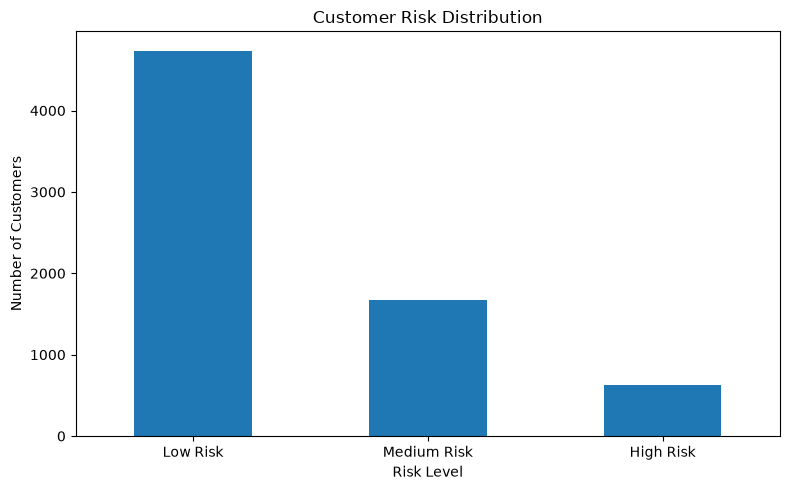

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

risk_distribution.plot(
    kind="bar"
)

plt.title("Customer Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
risk_percentage = (
    risk_distribution / total_customers * 100
).round(2)

print(risk_percentage)

RiskLevel
Low Risk       67.26
Medium Risk    23.77
High Risk       8.97
Name: count, dtype: float64


In [ ]:
revenue_by_risk = (
    risk_table.groupby("RiskLevel")["MonthlyCharges"]
    .sum()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
)

print(revenue_by_risk.round(2))

RiskLevel
Low Risk       281410.9
Medium Risk    122835.2
High Risk       51870.5
Name: MonthlyCharges, dtype: float64


In [ ]:
revenue_percentage = (
    revenue_by_risk / risk_table["MonthlyCharges"].sum() * 100
).round(2)

print(revenue_percentage)

RiskLevel
Low Risk       61.70
Medium Risk    26.93
High Risk      11.37
Name: MonthlyCharges, dtype: float64


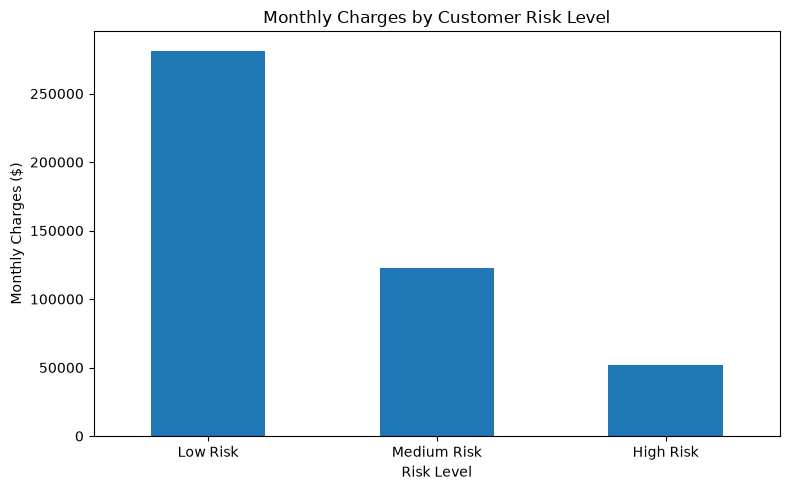

In [ ]:
revenue_by_risk.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Monthly Charges by Customer Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Monthly Charges ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
contract_churn = pd.crosstab(
    risk_table["Contract"],
    risk_table["PredictedChurn"],
    normalize="index"
) * 100

contract_churn = contract_churn.rename(
    columns={
        0: "No Churn",
        1: "Predicted Churn"
    }
)

print(contract_churn.round(2))

PredictedChurn  No Churn  Predicted Churn
Contract                                 
Month-to-month     42.04            57.96
One year           96.61             3.39
Two year           99.41             0.59


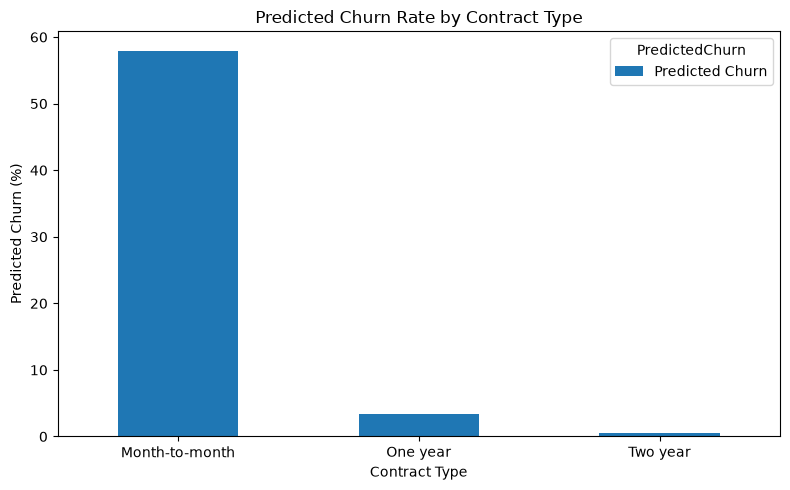

In [ ]:
contract_churn[["Predicted Churn"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Predicted Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Predicted Churn (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
internet_churn = pd.crosstab(
    risk_table["InternetService"],
    risk_table["PredictedChurn"],
    normalize="index"
) * 100

internet_churn = internet_churn.rename(
    columns={
        0: "No Churn",
        1: "Predicted Churn"
    }
)

print(internet_churn.round(2))

PredictedChurn   No Churn  Predicted Churn
InternetService                           
DSL                 80.38            19.62
Fiber optic         43.83            56.17
No                  93.97             6.03


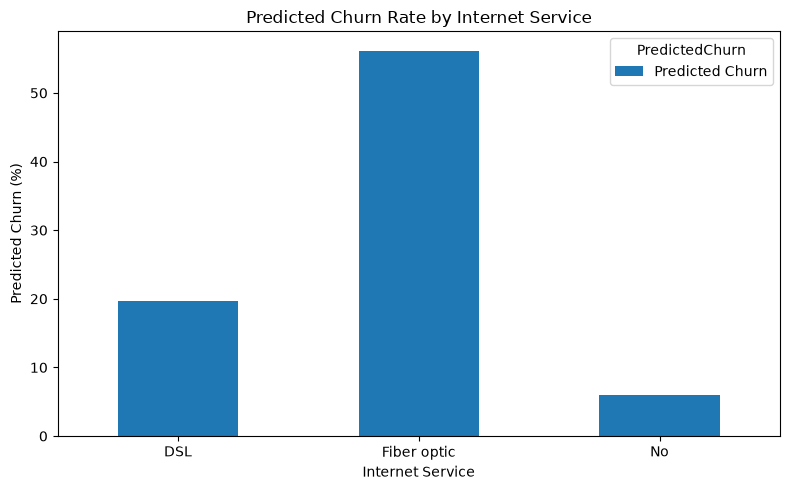

In [ ]:
internet_churn[["Predicted Churn"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Predicted Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Predicted Churn (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
payment_churn = pd.crosstab(
    risk_table["PaymentMethod"],
    risk_table["PredictedChurn"],
    normalize="index"
) * 100

payment_churn = payment_churn.rename(
    columns={
        0: "No Churn",
        1: "Predicted Churn"
    }
)

print(payment_churn.round(2))

PredictedChurn             No Churn  Predicted Churn
PaymentMethod                                       
Bank transfer (automatic)     84.84            15.16
Credit card (automatic)       85.55            14.45
Electronic check              37.08            62.92
Mailed check                  77.42            22.58


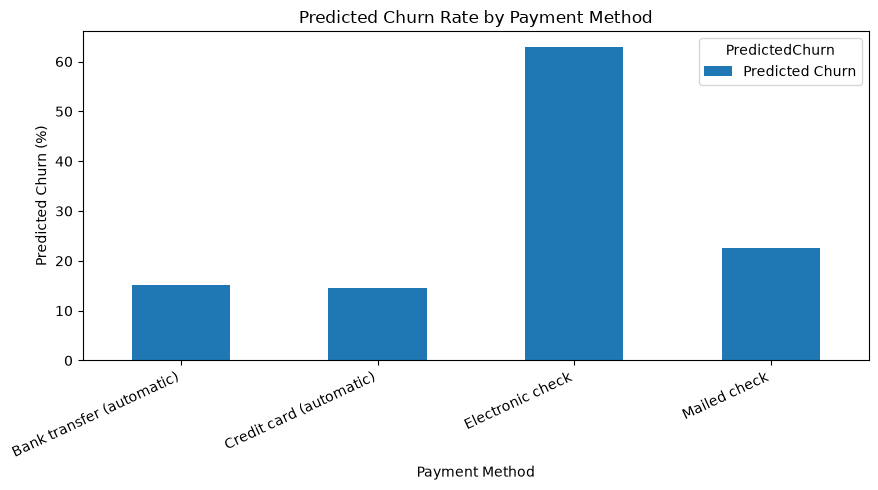

In [ ]:
payment_churn[["Predicted Churn"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Predicted Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Predicted Churn (%)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
high_risk_segments = (
    risk_table[risk_table["RiskLevel"] == "High Risk"]
    .groupby(
        ["Contract", "InternetService", "PaymentMethod"]
    )
    .agg(
        Customers=("CustomerID", "count"),
        MonthlyRevenue=("MonthlyCharges", "sum"),
        AvgChurnProbability=("ChurnProbability", "mean")
    )
    .sort_values(
        "Customers",
        ascending=False
    )
)

high_risk_segments.head(10)

Customers  \
Contract       InternetService PaymentMethod                          
Month-to-month Fiber optic     Electronic check                 464   
                               Mailed check                      58   
               DSL             Electronic check                  44   
               Fiber optic     Bank transfer (automatic)         33   
                               Credit card (automatic)           29   
               DSL             Mailed check                       3   
                               Bank transfer (automatic)          1   

                                                          MonthlyRevenue  \
Contract       InternetService PaymentMethod                               
Month-to-month Fiber optic     Electronic check                 39686.65   
                               Mailed check                      4684.00   
               DSL             Electronic check                  1746.30   
               Fiber optic     Bank transfer (automatic)         2980.00   
                               Credit card (automatic)           2641.50   
               DSL             Mailed check                        96.80   
                               Bank transfer (automatic)           35.25   

                                                          AvgChurnProbability  
Contract       InternetService PaymentMethod                                   
Month-to-month Fiber optic     Electronic check                      0.802153  
                               Mailed check                          0.777053  
               DSL             Electronic check                      0.753396  
               Fiber optic     Bank transfer (automatic)             0.798661  
                               Credit card (automatic)               0.793305  
               DSL             Mailed check                          0.759347  
                               Bank transfer (automatic)             0.708922

In [ ]:
high_risk_segments["AvgChurnProbability"] = (
    high_risk_segments["AvgChurnProbability"] * 100
).round(2)

high_risk_segments["MonthlyRevenue"] = (
    high_risk_segments["MonthlyRevenue"].round(2)
)

high_risk_segments.head(10)

Customers  \
Contract       InternetService PaymentMethod                          
Month-to-month Fiber optic     Electronic check                 464   
                               Mailed check                      58   
               DSL             Electronic check                  44   
               Fiber optic     Bank transfer (automatic)         33   
                               Credit card (automatic)           29   
               DSL             Mailed check                       3   
                               Bank transfer (automatic)          1   

                                                          MonthlyRevenue  \
Contract       InternetService PaymentMethod                               
Month-to-month Fiber optic     Electronic check                 39686.65   
                               Mailed check                      4684.00   
               DSL             Electronic check                  1746.30   
               Fiber optic     Bank transfer (automatic)         2980.00   
                               Credit card (automatic)           2641.50   
               DSL             Mailed check                        96.80   
                               Bank transfer (automatic)           35.25   

                                                          AvgChurnProbability  
Contract       InternetService PaymentMethod                                   
Month-to-month Fiber optic     Electronic check                         80.22  
                               Mailed check                             77.71  
               DSL             Electronic check                         75.34  
               Fiber optic     Bank transfer (automatic)                79.87  
                               Credit card (automatic)                  79.33  
               DSL             Mailed check                             75.93  
                               Bank transfer (automatic)                70.89

In [ ]:
top_revenue_risk = (
    risk_table[risk_table["PredictedChurn"] == 1]
    .sort_values(
        "MonthlyCharges",
        ascending=False
    )
    .head(10)
)

top_revenue_risk[
    [
        "CustomerID",
        "ChurnProbability",
        "RiskLevel",
        "MonthlyCharges",
        "Contract",
        "InternetService",
        "PaymentMethod"
    ]
]

,CustomerID,ChurnProbability,RiskLevel,MonthlyCharges,Contract,InternetService,PaymentMethod
5127,8199-ZLLSA,0.434053,Medium Risk,118.35,One year,Fiber optic,Bank transfer (automatic)
3299,4282-MSACW,0.384051,Medium Risk,117.20,One year,Fiber optic,Credit card (automatic)
1770,7279-BUYWN,0.421573,Medium Risk,113.20,Month-to-month,Fiber optic,Electronic check
440,0771-WLCLA,0.448434,Medium Risk,112.95,Month-to-month,Fiber optic,Electronic check
2265,1583-IHQZE,0.614379,Medium Risk,112.95,Month-to-month,Fiber optic,Mailed check
3875,2403-BCASL,0.379082,Medium Risk,111.95,One year,Fiber optic,Electronic check
3669,2587-EKXTS,0.390202,Medium Risk,111.50,Month-to-month,Fiber optic,Electronic check
1568,3292-PBZEJ,0.722698,High Risk,111.40,Month-to-month,Fiber optic,Electronic check
818,0115-TFERT,0.599462,Medium Risk,111.20,Month-to-month,Fiber optic,Electronic check
6605,7632-MNYOY,0.512629,Medium Risk,110.90,One year,Fiber optic,Credit card (automatic)


In [ ]:
dashboard_data = risk_table[
    [
        "CustomerID",
        "tenure",
        "MonthlyCharges",
        "Contract",
        "InternetService",
        "TechSupport",
        "PaymentMethod",
        "ChurnProbability",
        "PredictedChurn",
        "RiskLevel",
        "RecommendedAction"
    ]
].copy()

print("Dashboard dataset shape:", dashboard_data.shape)
dashboard_data.head()

Dashboard dataset shape: (7043, 11)


,CustomerID,tenure,MonthlyCharges,Contract,InternetService,TechSupport,PaymentMethod,ChurnProbability,PredictedChurn,RiskLevel,RecommendedAction
0,7590-VHVEG,1,29.85,Month-to-month,DSL,No,Electronic check,0.720205,1,High Risk,Offer annual contract discount + proactive sup...
1,5575-GNVDE,34,56.95,One year,DSL,No,Mailed check,0.030386,0,Low Risk,Continue regular engagement
2,3668-QPYBK,2,53.85,Month-to-month,DSL,No,Mailed check,0.369843,1,Medium Risk,Offer contract upgrade incentive
3,7795-CFOCW,45,42.30,One year,DSL,Yes,Bank transfer (automatic),0.039593,0,Low Risk,Continue regular engagement
4,9237-HQITU,2,70.70,Month-to-month,Fiber optic,No,Electronic check,0.661154,1,Medium Risk,Offer contract upgrade incentive


In [ ]:
dashboard_data["MonthlyRevenueAtRisk"] = np.where(
    dashboard_data["PredictedChurn"] == 1,
    dashboard_data["MonthlyCharges"],
    0
)

print(
    "Total revenue at risk: $",
    round(
        dashboard_data["MonthlyRevenueAtRisk"].sum(),
        2
    )
)

Total revenue at risk: $ 174705.7


In [ ]:
dashboard_data["ChurnProbabilityPct"] = (
    dashboard_data["ChurnProbability"] * 100
).round(2)

In [ ]:
dashboard_data = dashboard_data.drop(
    columns=["ChurnProbability"]
)

dashboard_data.head()

,CustomerID,tenure,MonthlyCharges,Contract,InternetService,TechSupport,PaymentMethod,PredictedChurn,RiskLevel,RecommendedAction,MonthlyRevenueAtRisk,ChurnProbabilityPct
0,7590-VHVEG,1,29.85,Month-to-month,DSL,No,Electronic check,1,High Risk,Offer annual contract discount + proactive sup...,29.85,72.02
1,5575-GNVDE,34,56.95,One year,DSL,No,Mailed check,0,Low Risk,Continue regular engagement,0.00,3.04
2,3668-QPYBK,2,53.85,Month-to-month,DSL,No,Mailed check,1,Medium Risk,Offer contract upgrade incentive,53.85,36.98
3,7795-CFOCW,45,42.30,One year,DSL,Yes,Bank transfer (automatic),0,Low Risk,Continue regular engagement,0.00,3.96
4,9237-HQITU,2,70.70,Month-to-month,Fiber optic,No,Electronic check,1,Medium Risk,Offer contract upgrade incentive,70.70,66.12


In [ ]:
dashboard_data.to_csv(
    "../data/processed/churn_dashboard_data.csv",
    index=False
)

print("Final dashboard dataset saved successfully!")

Final dashboard dataset saved successfully!


In [ ]:
import os

file_path = "../data/processed/churn_dashboard_data.csv"

print("File exists:", os.path.exists(file_path))
print("File path:", os.path.abspath(file_path))

File exists: True
File path: c:\Users\admin\Desktop\customer-churn-project\data\processed\churn_dashboard_data.csv
